# 04 - External Testing (with Neural Network added)

**Meshwa Patel - 501390663**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_style("whitegrid")

## Part A - Transfer test on `insurance_claims__2_.csv`

This dataset has the same column names as my main data, so I can train on my
data and then apply the model straight to this one.

In [2]:
# load and clean my main dataset again
main = pd.read_csv("car_insurance_fraud_dataset.csv")
main["authorities_contacted"] = main["authorities_contacted"].fillna("None")
main["fraud"] = (main["fraud_reported"] == "Y").astype(int)

# load the test dataset
ext = pd.read_csv("insurance_claims (2).csv")
print("Test dataset rows:", len(ext))
print("Test dataset fraud rate:", round((ext["fraud_reported"] == "Y").mean() * 100, 2), "%")

Test dataset rows: 1000
Test dataset fraud rate: 24.7 %


In [3]:
ext["collision_type"] = ext["collision_type"].str.replace(" Collision", "", regex=False)
ext["collision_type"] = ext["collision_type"].replace("?", "Unknown")
ext["police_report_available"] = ext["police_report_available"].replace(
    {"YES": "Yes", "NO": "No", "?": "No"})
ext["authorities_contacted"] = ext["authorities_contacted"].fillna("None").replace("?", "None")
ext["insured_sex"] = ext["insured_sex"].str.upper()
ext["y"] = (ext["fraud_reported"] == "Y").astype(int)

print("Categories fixed.")

Categories fixed.


In [4]:
shared_num = ["policy_annual_premium", "total_claim_amount", "incident_hour_of_the_day",
              "number_of_vehicles_involved", "bodily_injuries", "witnesses"]
shared_cat = ["policy_state", "incident_state", "incident_type", "collision_type",
              "incident_severity", "authorities_contacted", "police_report_available",
              "insured_sex", "insured_education_level"]
shared = shared_num + shared_cat

print("Shared features:", len(shared))

Shared features: 15


In [5]:
prep_shared = ColumnTransformer([
    ("num", StandardScaler(), shared_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), shared_cat)
])

transfer_lr = Pipeline([
    ("prep", prep_shared),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
transfer_lr.fit(main[shared], main["fraud"])

transfer_nn = Pipeline([
    ("prep", prep_shared),
    ("smote", SMOTE(random_state=42)),
    ("model", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300,
                            early_stopping=True, random_state=42))
])
transfer_nn.fit(main[shared], main["fraud"])

print("Both models trained on my main dataset.")

Both models trained on my main dataset.


In [6]:
X_ext = ext[shared]
y_ext = ext["y"]

probs_lr = transfer_lr.predict_proba(X_ext)[:, 1]
probs_nn = transfer_nn.predict_proba(X_ext)[:, 1]

print("TRANSFER TEST RESULTS (insurance_claims__2_.csv)")
print()
print("Logistic Regression + SMOTE:")
print("   AUC:", round(roc_auc_score(y_ext, probs_lr), 3))
print("Neural Network + SMOTE:")
print("   AUC:", round(roc_auc_score(y_ext, probs_nn), 3))
print()
print("Both are very low. An AUC below 0.5 is worse than random guessing.")

TRANSFER TEST RESULTS (insurance_claims__2_.csv)

Logistic Regression + SMOTE:
   AUC: 0.374
Neural Network + SMOTE:
   AUC: 0.449

Both are very low. An AUC below 0.5 is worse than random guessing.


In [7]:
Xa, Xb, ya, yb = train_test_split(X_ext, y_ext, test_size=0.30,
                                  random_state=42, stratify=y_ext)

indomain = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), shared_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), shared_cat)])),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
indomain.fit(Xa, ya)
probs_in = indomain.predict_proba(Xb)[:, 1]

print("IN-DOMAIN TEST (train and test inside this same dataset)")
print("AUC:", round(roc_auc_score(yb, probs_in), 3))
print()
print("This score is much better. So the dataset has real fraud signal in it.")
print("That means the low transfer score is because MY main dataset is different,")
print("not because the test dataset is bad. This is called a domain gap.")

IN-DOMAIN TEST (train and test inside this same dataset)
AUC: 0.784

This score is much better. So the dataset has real fraud signal in it.
That means the low transfer score is because MY main dataset is different,
not because the test dataset is bad. This is called a domain gap.


## Part B - Benchmark on `fraud_oracle.csv`


In [8]:
oracle = pd.read_csv("fraud_oracle.csv")
print("Rows:", len(oracle))
print("Fraud rate:", round(oracle["FraudFound_P"].mean() * 100, 2), "%")

Rows: 15420
Fraud rate: 5.99 %


In [9]:
y_o = oracle["FraudFound_P"]
X_o = oracle.drop(columns=["FraudFound_P", "PolicyNumber"])

# Age has 0 values which are not real ages, so I replace them with the median
X_o["Age"] = X_o["Age"].replace(0, X_o["Age"].median())

num_o = X_o.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_o = X_o.select_dtypes(include=["object"]).columns.tolist()

Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(X_o, y_o, test_size=0.30,
                                              random_state=42, stratify=y_o)

prep_o = ColumnTransformer([
    ("num", StandardScaler(), num_o),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_o)
])

In [10]:
def run_model(classifier, name, prep, Xtr, ytr, Xte, yte):
    pipe = Pipeline([
        ("prep", prep),
        ("smote", SMOTE(random_state=42)),
        ("model", classifier)
    ])
    pipe.fit(Xtr, ytr)
    probs = pipe.predict_proba(Xte)[:, 1]
    preds = pipe.predict(Xte)
    return {
        "Model": name,
        "Precision": round(precision_score(yte, preds, zero_division=0), 3),
        "Recall": round(recall_score(yte, preds), 3),
        "F1": round(f1_score(yte, preds), 3),
        "AUC": round(roc_auc_score(yte, probs), 3)
    }, probs


oracle_results = []
oracle_probs = {}

res, pr = run_model(LogisticRegression(max_iter=1000, random_state=42),
                    "Logistic Regression", prep_o, Xo_tr, yo_tr, Xo_te, yo_te)
oracle_results.append(res); oracle_probs["Logistic Regression"] = pr

res, pr = run_model(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                    "Random Forest", prep_o, Xo_tr, yo_tr, Xo_te, yo_te)
oracle_results.append(res); oracle_probs["Random Forest"] = pr

res, pr = run_model(XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                  eval_metric="logloss", random_state=42, n_jobs=-1),
                    "XGBoost", prep_o, Xo_tr, yo_tr, Xo_te, yo_te)
oracle_results.append(res); oracle_probs["XGBoost"] = pr

res, pr = run_model(MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300,
                                  early_stopping=True, random_state=42),
                    "Neural Network", prep_o, Xo_tr, yo_tr, Xo_te, yo_te)
oracle_results.append(res); oracle_probs["Neural Network"] = pr

oracle_table = pd.DataFrame(oracle_results)
print("BENCHMARK RESULTS (fraud_oracle.csv) - all 4 models")
oracle_table

BENCHMARK RESULTS (fraud_oracle.csv) - all 4 models


,Model,Precision,Recall,F1,AUC
0,Logistic Regression,0.131,0.809,0.226,0.796
1,Random Forest,1.000,0.007,0.014,0.822
2,XGBoost,0.600,0.054,0.099,0.855
3,Neural Network,0.170,0.202,0.185,0.755


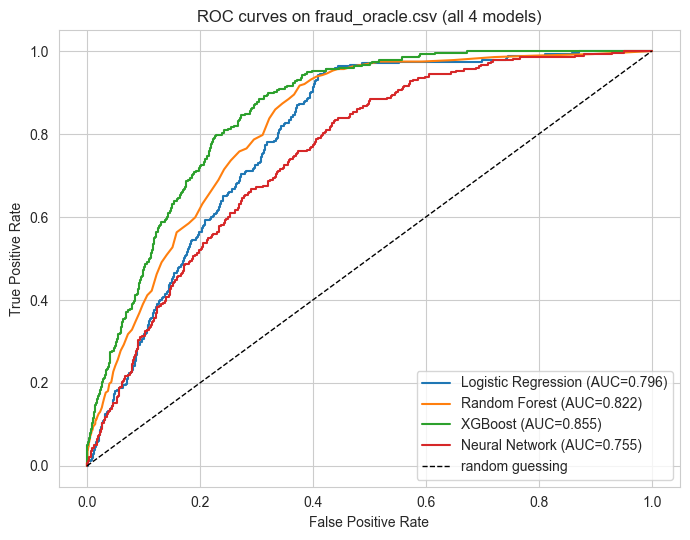

In [11]:
plt.figure(figsize=(7, 5.5))
for name, probs in oracle_probs.items():
    fpr, tpr, _ = roc_curve(yo_te, probs)
    auc = roc_auc_score(yo_te, probs)
    plt.plot(fpr, tpr, label=name + " (AUC=" + str(round(auc, 3)) + ")")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on fraud_oracle.csv (all 4 models)")
plt.legend()
plt.tight_layout()
plt.savefig("30_benchmark_roc_4models.png", dpi=110, bbox_inches="tight")
plt.show()

## Part C - Benchmark on `insurance_fraud_data__1_.csv`

In [12]:
data2 = pd.read_csv("insurance_fraud_data (1).csv")
data2 = data2.dropna(subset=["fraud reported"])

y2 = (data2["fraud reported"].astype(str).str.strip().str.upper() == "Y").astype(int)
X2 = data2.drop(columns=["fraud reported", "claim_number", "claim_date"])

# some columns are numbers stored as text
for col in ["injury_claim", "age_of_vehicle"]:
    if col in X2.columns:
        X2[col] = pd.to_numeric(X2[col], errors="coerce")

num2 = X2.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat2 = X2.select_dtypes(include=["object"]).columns.tolist()

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.30,
                                              random_state=42, stratify=y2)

prep2 = ColumnTransformer([
    ("num", SkPipeline([("fill", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())]), num2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat2)
])

print("Rows:", len(X2))
print("Fraud rate:", round(y2.mean() * 100, 2), "%")

Rows: 11994
Fraud rate: 24.6 %


In [13]:
results2 = []

res, _ = run_model(LogisticRegression(max_iter=1000, random_state=42),
                   "Logistic Regression", prep2, X2_tr, y2_tr, X2_te, y2_te)
results2.append(res)

res, _ = run_model(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                   "Random Forest", prep2, X2_tr, y2_tr, X2_te, y2_te)
results2.append(res)

res, _ = run_model(XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                 eval_metric="logloss", random_state=42, n_jobs=-1),
                   "XGBoost", prep2, X2_tr, y2_tr, X2_te, y2_te)
results2.append(res)

res, _ = run_model(MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300,
                                 early_stopping=True, random_state=42),
                   "Neural Network", prep2, X2_tr, y2_tr, X2_te, y2_te)
results2.append(res)

table2 = pd.DataFrame(results2)
print("BENCHMARK RESULTS (insurance_fraud_data__1_.csv) - all 4 models")
table2

BENCHMARK RESULTS (insurance_fraud_data__1_.csv) - all 4 models


,Model,Precision,Recall,F1,AUC
0,Logistic Regression,0.297,0.629,0.403,0.624
1,Random Forest,0.808,0.114,0.200,0.608
2,XGBoost,0.594,0.147,0.236,0.630
3,Neural Network,0.317,0.367,0.340,0.604


## Part E - All the testing results together

In [14]:
summary = pd.DataFrame([
    {"Dataset": "My main data", "Test type": "Held-out test", "Best AUC": 0.725},
    {"Dataset": "insurance_claims (2)", "Test type": "Transfer test",
     "Best AUC": round(roc_auc_score(y_ext, probs_lr), 3)},
    {"Dataset": "insurance_claims (2)", "Test type": "In-domain check",
     "Best AUC": round(roc_auc_score(yb, probs_in), 3)},
    {"Dataset": "fraud_oracle", "Test type": "Benchmark (4 models)",
     "Best AUC": oracle_table["AUC"].max()},
    {"Dataset": "insurance_fraud_data (1)", "Test type": "Benchmark (4 models)",
     "Best AUC": table2["AUC"].max()},
])

print("ALL TESTING RESULTS")
summary

ALL TESTING RESULTS


,Dataset,Test type,Best AUC
0,My main data,Held-out test,0.725
1,insurance_claims (2),Transfer test,0.374
2,insurance_claims (2),In-domain check,0.784
3,fraud_oracle,Benchmark (4 models),0.855
4,insurance_fraud_data (1),Benchmark (4 models),0.630


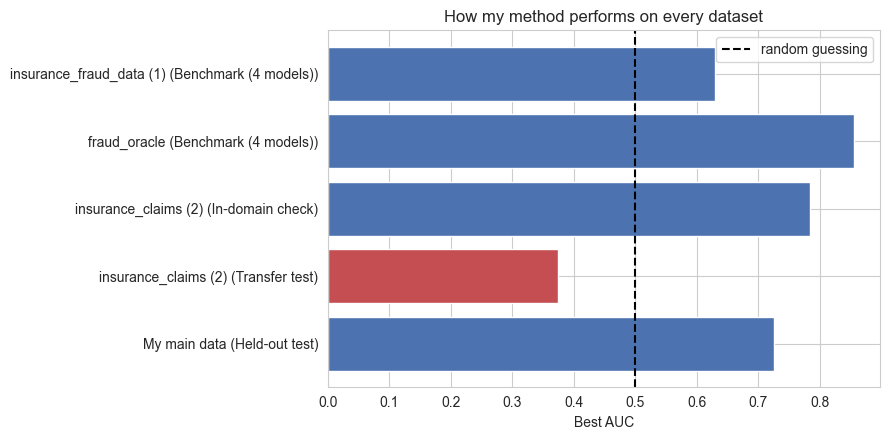

In [15]:
plt.figure(figsize=(9, 4.5))
colors = ["#C44E52" if t == "Transfer test" else "#4C72B0" for t in summary["Test type"]]
plt.barh(summary["Dataset"] + " (" + summary["Test type"] + ")",
         summary["Best AUC"], color=colors)
plt.axvline(0.5, color="black", linestyle="--", label="random guessing")
plt.xlabel("Best AUC")
plt.title("How my method performs on every dataset")
plt.legend()
plt.tight_layout()
plt.savefig("31_all_testing_results.png", dpi=110, bbox_inches="tight")
plt.show()